# Milestone 1 — Inspeção Inicial dos Dados

Nesta fase é realizada a primeira exploração do conjunto de dados Telco Customer Churn, com o objetivo de compreender a sua estrutura, dimensão, tipos de variáveis, valores em falta, duplicados e distribuição da variável Churn.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

csv_files = list(Path('/kaggle/input').rglob('*.csv'))

print("Ficheiros CSV encontrados:")
for file in csv_files:
    print(file)

df = pd.read_csv(csv_files[0])

Ficheiros CSV encontrados:
/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


## Visualização inicial dos dados

Nesta secção são apresentadas as primeiras linhas do dataset e a sua dimensão, para perceber a estrutura geral da tabela.

In [2]:
display(df.head())

print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Número de linhas: 7043
Número de colunas: 21


## Inspeção geral e verificação inicial da qualidade dos dados

Nesta célula são analisados os tipos de dados, estatísticas descritivas, valores nulos, duplicados, distribuição da variável Churn e possíveis problemas na coluna TotalCharges.

In [3]:
print("\nInformação geral do dataset:")
df.info()

print("\nEstatística descritiva das variáveis numéricas:")
display(df.describe())

print("\nEstatística descritiva das variáveis categóricas:")
display(df.describe(include='object'))

print("\nValores nulos por coluna:")
display(df.isnull().sum().to_frame("Valores nulos"))

print("\nNúmero de linhas duplicadas:")
print(df.duplicated().sum())

print("\nDistribuição da variável Churn:")
display(df['Churn'].value_counts().to_frame("Contagem"))

print("\nDistribuição percentual da variável Churn:")
display((df['Churn'].value_counts(normalize=True) * 100).round(2).to_frame("Percentagem (%)"))

print("\nTipo de dados da coluna TotalCharges:")
print(df['TotalCharges'].dtype)

# Conversão temporária da coluna TotalCharges para verificar problemas
df['TotalCharges_num'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nNúmero de valores problemáticos/em falta após conversão de TotalCharges:")
print(df['TotalCharges_num'].isnull().sum())

print("\nLinhas com TotalCharges problemático:")
display(df[df['TotalCharges_num'].isnull()])


Informação geral do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBil

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Estatística descritiva das variáveis categóricas:


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174



Valores nulos por coluna:


...

,Contagem
Churn,
No,5174
Yes,1869



Distribuição percentual da variável Churn:


,Percentagem (%)
Churn,
No,73.46
Yes,26.54



Tipo de dados da coluna TotalCharges:
object

Número de valores problemáticos/em falta após conversão de TotalCharges:
11

Linhas com TotalCharges problemático:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_num
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No,NaN
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No,NaN
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,,No,NaN
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No,NaN
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No,NaN
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No,NaN
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No,NaN
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No,NaN
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No,NaN
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,No,Two year,No,Mailed check,73.35,,No,NaN


## Síntese da inspeção inicial

A inspeção inicial permitiu confirmar que o dataset tem 7043 linhas e 21 colunas. Também foram analisados os tipos de dados, valores nulos, duplicados e a distribuição da variável Churn. Verificou-se ainda que a coluna TotalCharges se encontra como variável categórica, apesar de representar valores monetários, pelo que deverá ser tratada numa fase posterior.

# Milestone 2 — Exploração dos Dados

Nesta fase é feita uma análise exploratória mais detalhada, focada nas distribuições das variáveis numéricas, na frequência das variáveis categóricas e na identificação de variáveis relevantes para a diferenciação de clientes.

Como o projeto segue uma abordagem de aprendizagem não supervisionada, a variável `Churn` não será tratada como variável-alvo. A análise será centrada em atributos que podem ajudar a distinguir perfis de clientes, como tempo de permanência, encargos mensais, encargos totais, tipo de contrato, serviços contratados e método de pagamento.

In [4]:
# Milestone 2 — Preparação inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Criar pasta para guardar figuras
figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

# Criar uma cópia do dataset para a Milestone 2
df_m2 = df.copy()

# Converter TotalCharges para numérico
df_m2["TotalCharges"] = pd.to_numeric(df_m2["TotalCharges"], errors="coerce")

# Verificar valores em falta após conversão
missing_totalcharges = df_m2["TotalCharges"].isna().sum()

print("Valores em falta em TotalCharges após conversão:")
print(missing_totalcharges)

display(
    df_m2[df_m2["TotalCharges"].isna()][
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
    ]
)

Valores em falta em TotalCharges após conversão:
11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [5]:
# Tratamento de valores em falta em TotalCharges

# Verificar se os valores em falta correspondem a clientes com tenure = 0
missing_rows = df_m2[df_m2["TotalCharges"].isna()]

print("Distribuição de tenure nas linhas com TotalCharges em falta:")
display(missing_rows["tenure"].value_counts().to_frame("Contagem"))

# Estratégia:
# Se TotalCharges está em falta e tenure = 0, assume-se TotalCharges = 0
condition = df_m2["TotalCharges"].isna() & (df_m2["tenure"] == 0)

df_m2.loc[condition, "TotalCharges"] = 0

print("Valores em falta em TotalCharges após tratamento:")
print(df_m2["TotalCharges"].isna().sum())

Distribuição de tenure nas linhas com TotalCharges em falta:


,Contagem
tenure,
0,11


Valores em falta em TotalCharges após tratamento:
0


## 1. Distribuição das variáveis numéricas

Foram analisadas as principais variáveis numéricas relevantes para a segmentação de clientes:

- `tenure`;
- `MonthlyCharges`;
- `TotalCharges`.

Estas variáveis são importantes porque representam, respetivamente, o tempo de permanência do cliente, o valor mensal pago e o valor total acumulado ao longo da relação com a empresa.

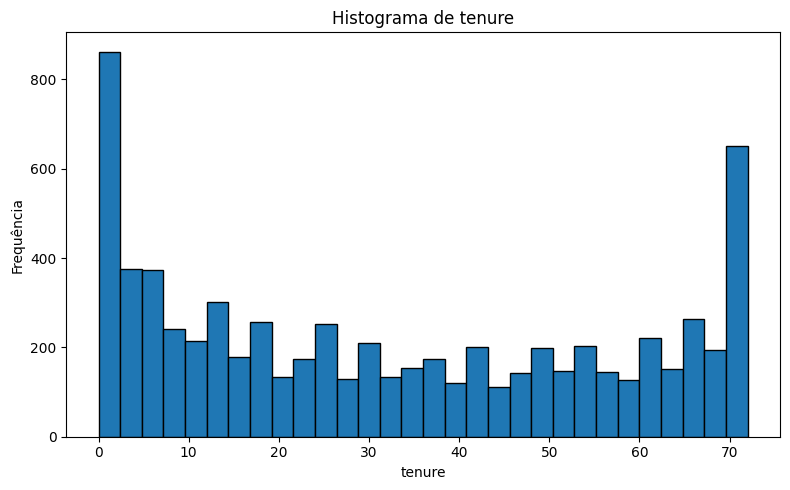

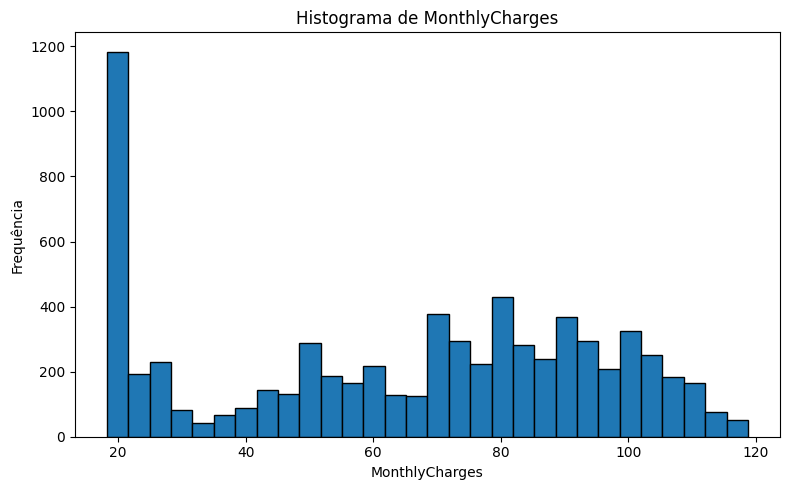

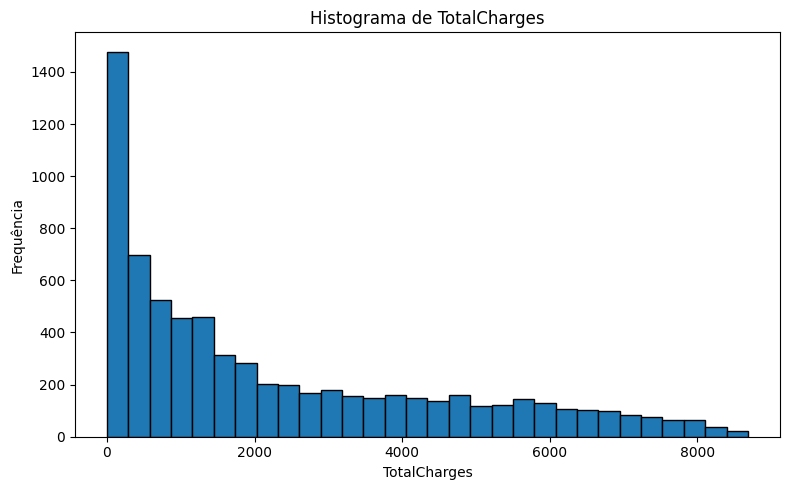

In [6]:
# Histogramas das variáveis numéricas

numeric_vars = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_vars:
    plt.figure(figsize=(8, 5))
    plt.hist(df_m2[col].dropna(), bins=30, edgecolor="black")
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.tight_layout()
    
    # Guardar figura
    plt.savefig(figures_path / f"histograma_{col}.png", dpi=300)
    
    plt.show()

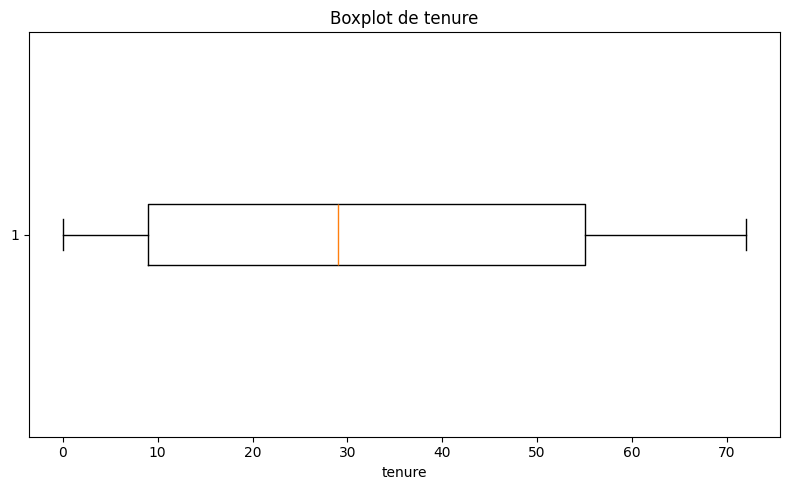

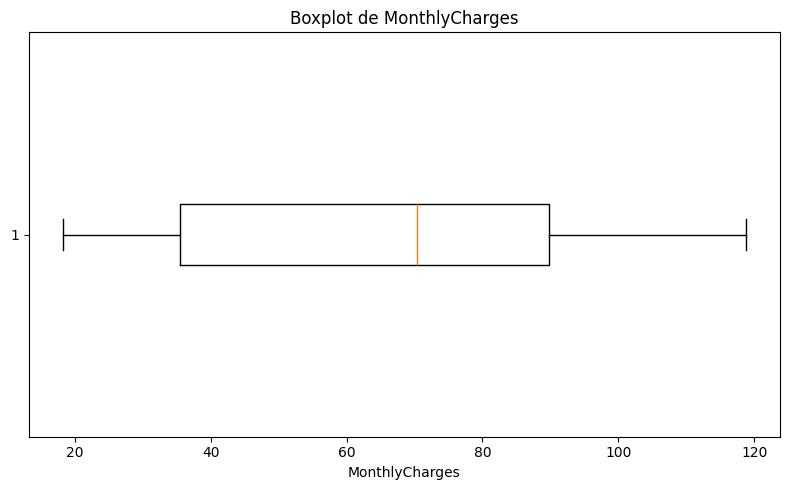

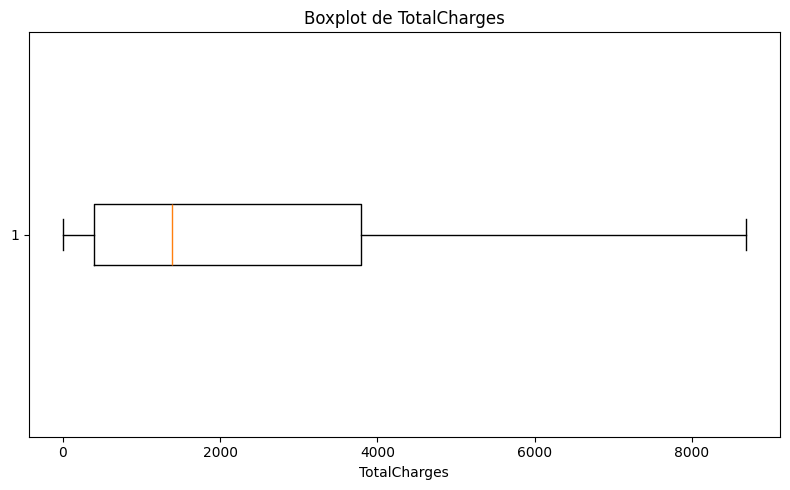

In [7]:
# Boxplots das variáveis numéricas

for col in numeric_vars:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df_m2[col].dropna(), vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    
    # Guardar figura
    plt.savefig(figures_path / f"boxplot_{col}.png", dpi=300)
    
    plt.show()

In [8]:
# Estatísticas descritivas das variáveis numéricas

numeric_summary = df_m2[numeric_vars].describe().T

numeric_summary["amplitude"] = numeric_summary["max"] - numeric_summary["min"]
numeric_summary["coef_variacao"] = numeric_summary["std"] / numeric_summary["mean"]

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,amplitude,coef_variacao
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00,72.0,0.758684
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75,100.5,0.464627
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80,8684.8,0.994324


## 2. Frequência das variáveis categóricas

Nesta secção são analisadas as frequências das variáveis categóricas. A variável `customerID` foi excluída por ser apenas um identificador. A variável `Churn` também foi excluída desta análise principal, porque o projeto está orientado para segmentação não supervisionada e não para classificação.

In [9]:
# Frequências das variáveis categóricas

# Identificar variáveis categóricas
categorical_vars = df_m2.select_dtypes(include="object").columns.tolist()

# Remover identificador e Churn da análise principal
categorical_vars = [
    col for col in categorical_vars 
    if col not in ["customerID", "Churn"]
]

print("Variáveis categóricas analisadas:")
print(categorical_vars)

for col in categorical_vars:
    print(f"\nFrequência absoluta e relativa de {col}:")
    
    freq_table = pd.DataFrame({
        "Contagem": df_m2[col].value_counts(),
        "Percentagem": df_m2[col].value_counts(normalize=True) * 100
    })
    
    freq_table["Percentagem"] = freq_table["Percentagem"].round(2)
    
    display(freq_table)

Variáveis categóricas analisadas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Frequência absoluta e relativa de gender:


,Contagem,Percentagem
gender,,
Male,3555,50.48
Female,3488,49.52



Frequência absoluta e relativa de Partner:


,Contagem,Percentagem
Partner,,
No,3641,51.7
Yes,3402,48.3



Frequência absoluta e relativa de Dependents:


...

,Contagem,Percentagem
Contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91



Frequência absoluta e relativa de PaperlessBilling:


,Contagem,Percentagem
PaperlessBilling,,
Yes,4171,59.22
No,2872,40.78



Frequência absoluta e relativa de PaymentMethod:


,Contagem,Percentagem
PaymentMethod,,
Electronic check,2365,33.58
Mailed check,1612,22.89
Bank transfer (automatic),1544,21.92
Credit card (automatic),1522,21.61


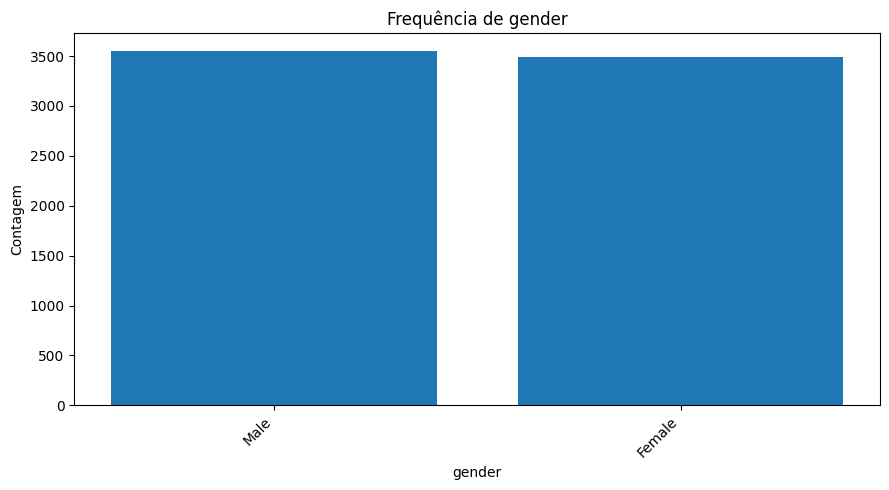

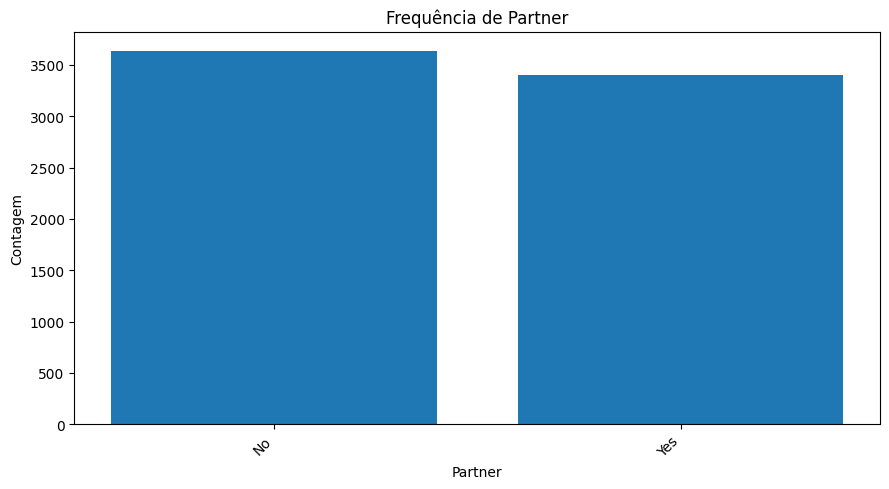

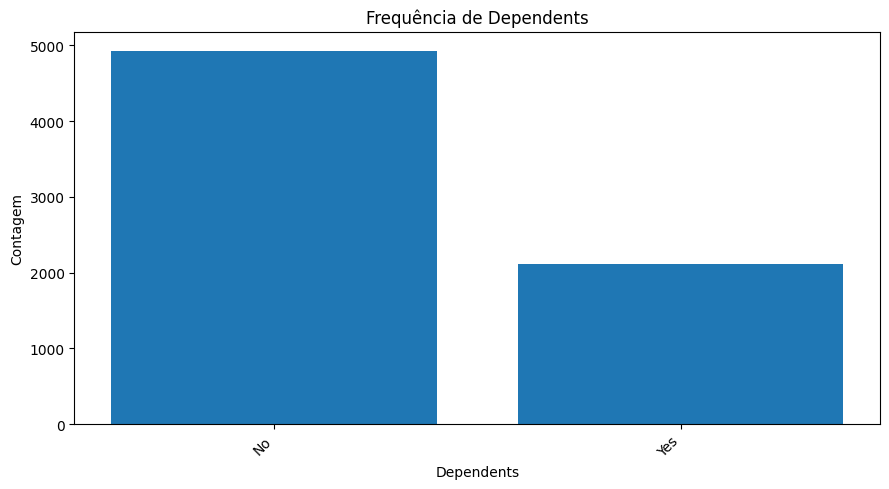

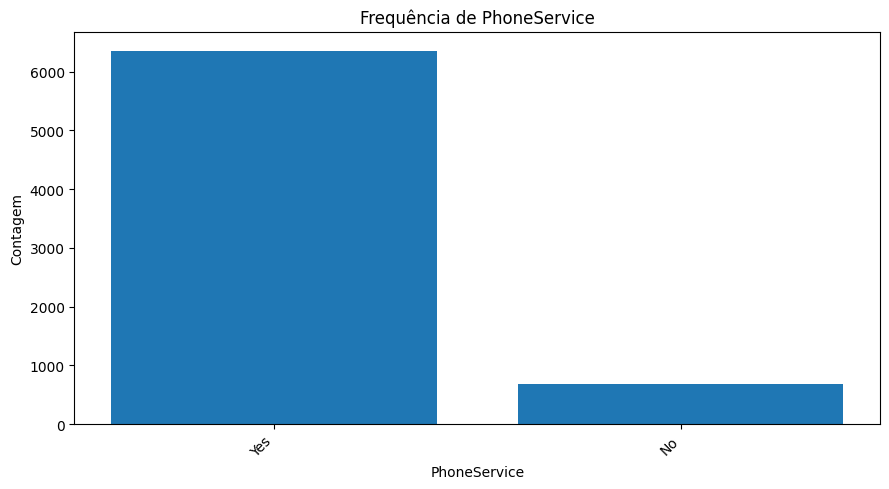

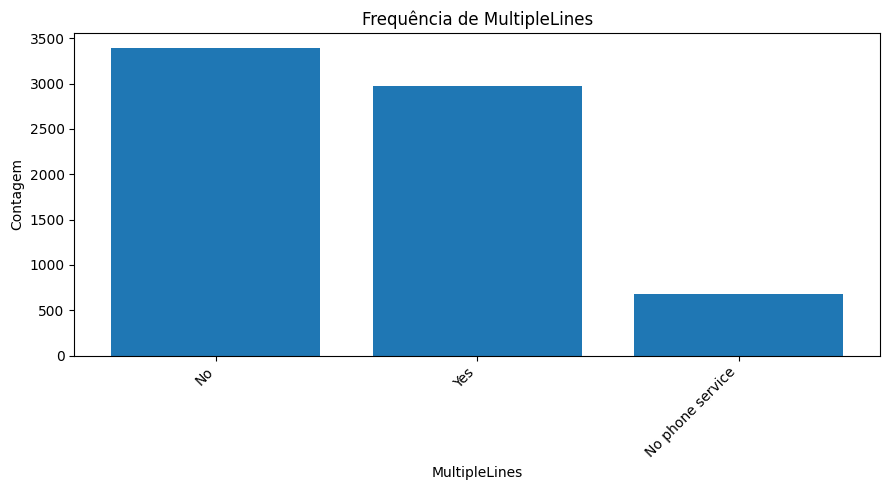

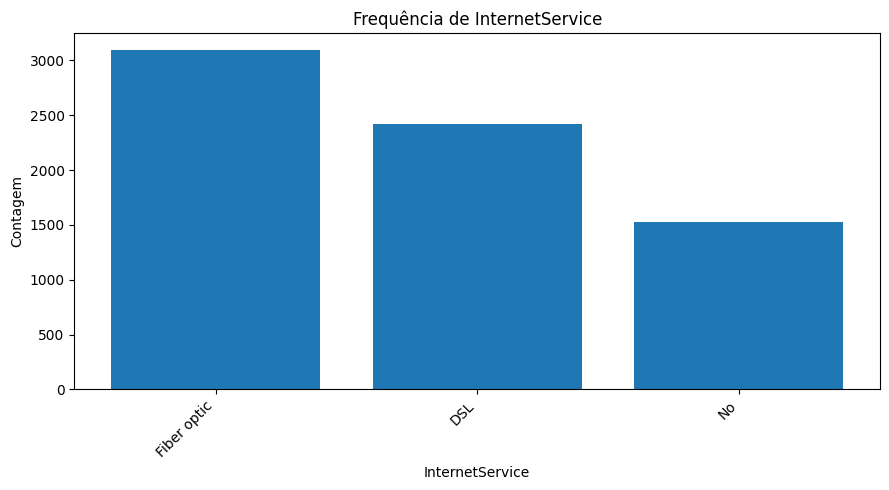

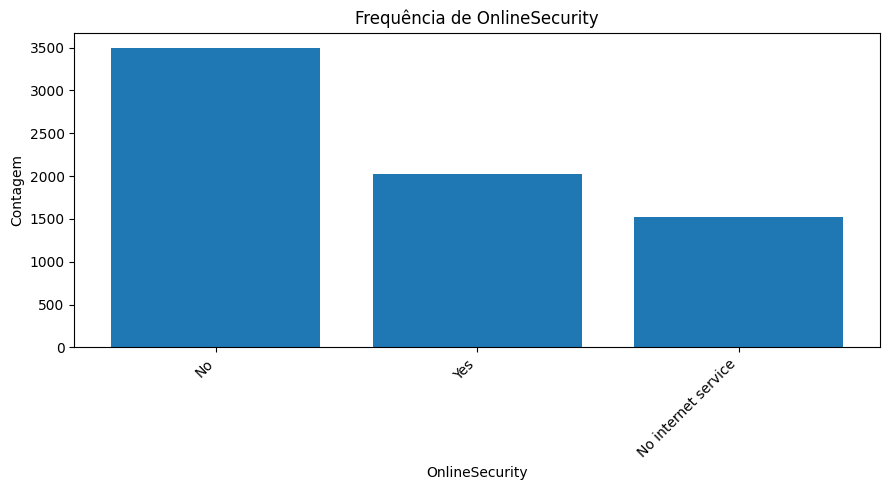

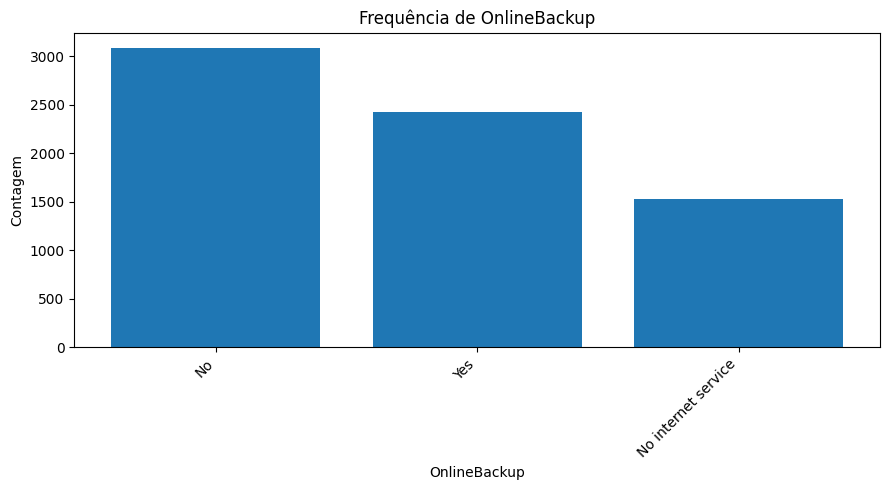

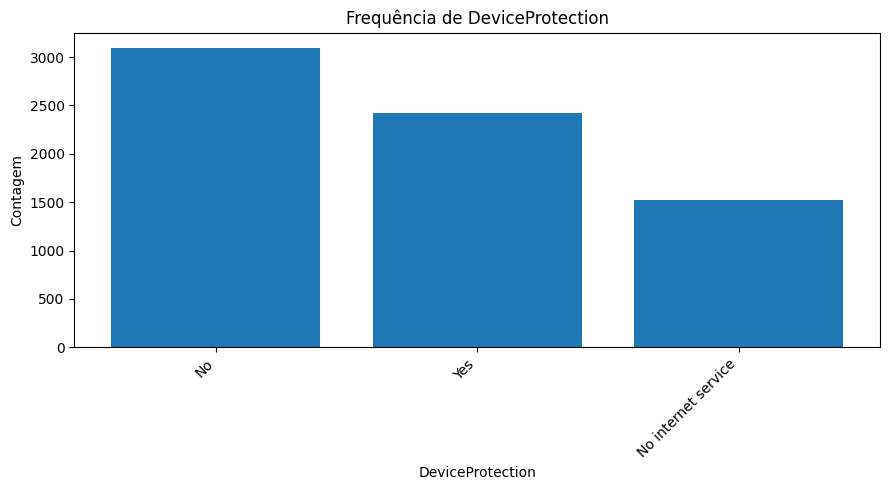

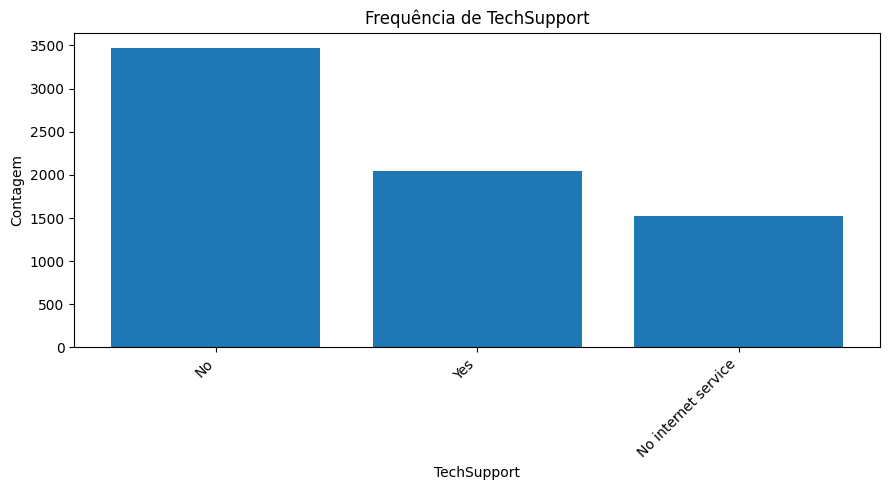

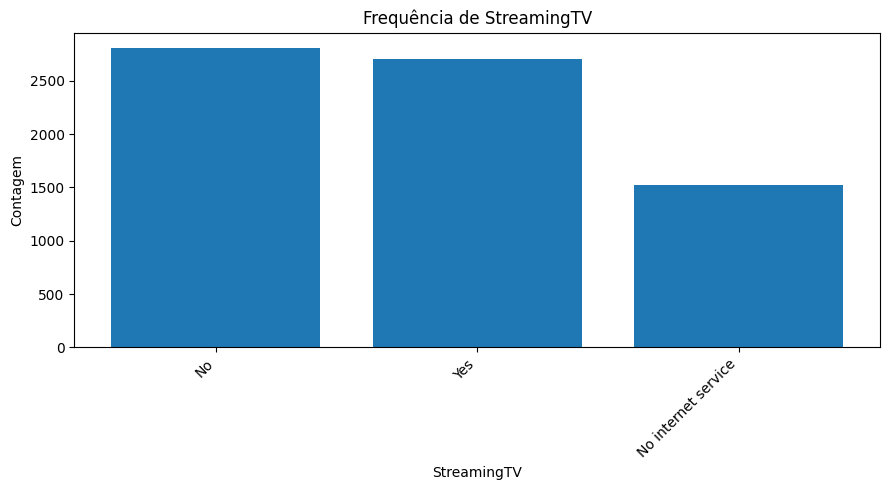

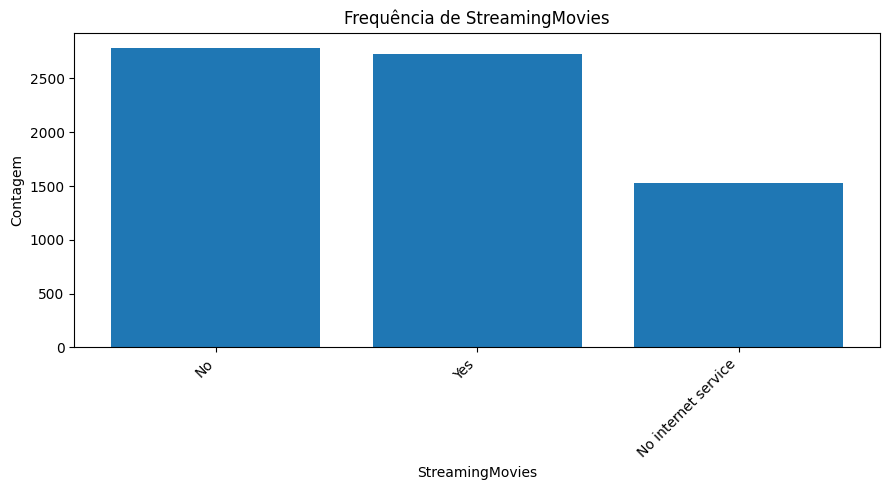

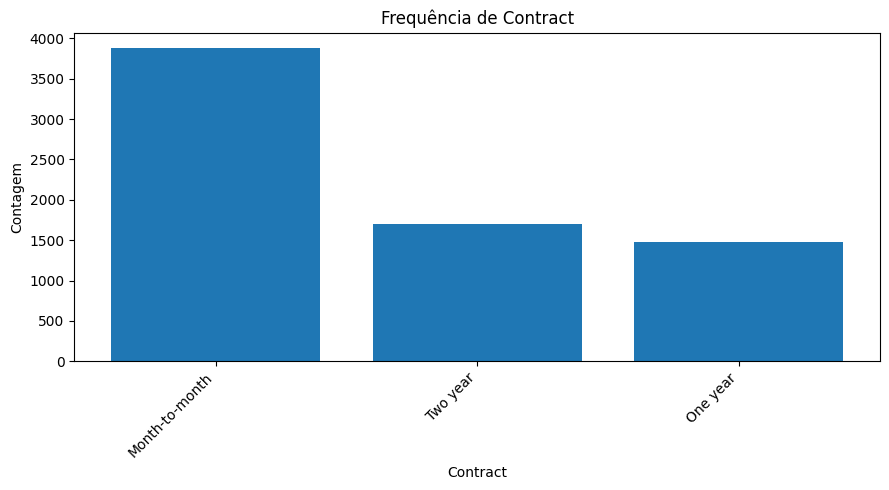

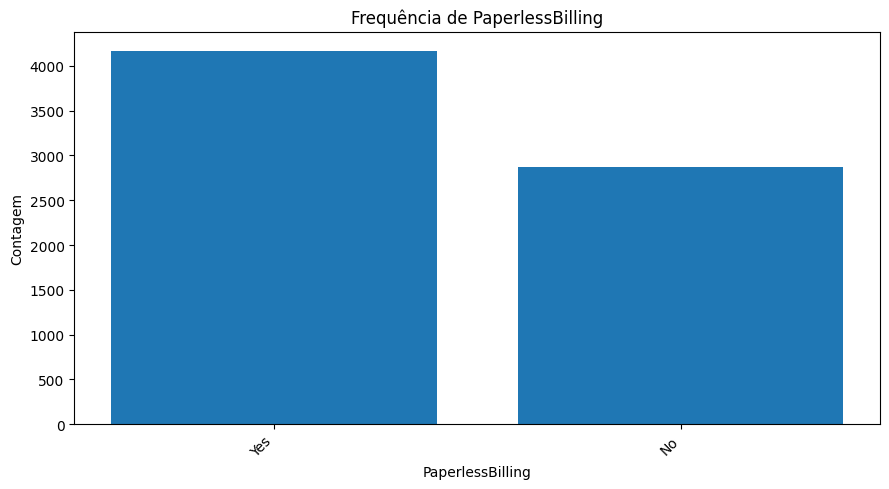

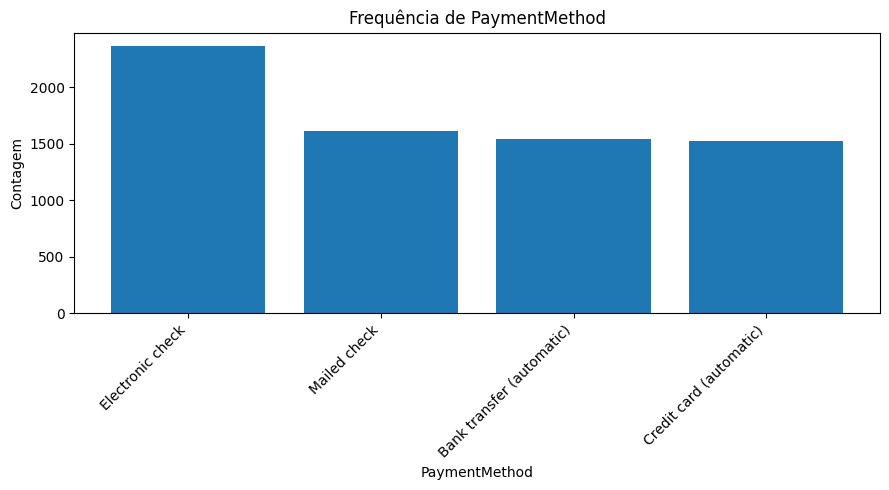

In [10]:
# Gráficos de barras das variáveis categóricas

for col in categorical_vars:
    plt.figure(figsize=(9, 5))
    
    counts = df_m2[col].value_counts()
    
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Frequência de {col}")
    plt.xlabel(col)
    plt.ylabel("Contagem")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    
    # Guardar figura
    safe_col_name = col.replace(" ", "_").replace("/", "_")
    plt.savefig(figures_path / f"frequencia_{safe_col_name}.png", dpi=300)
    
    plt.show()

## 3. Variáveis críticas para diferenciação dos clientes

Como o projeto segue uma abordagem não supervisionada, o foco não está em prever uma variável-alvo, mas sim em identificar variáveis que ajudam a diferenciar grupos de clientes.

Nesta fase, são consideradas especialmente relevantes as variáveis associadas a:

- tempo de permanência do cliente;
- valor mensal pago;
- valor total acumulado;
- tipo de contrato;
- serviços contratados;
- método de pagamento e faturação.

In [11]:
# Análise das variáveis numéricas mais diferenciadoras

critical_numeric_analysis = numeric_summary[
    ["mean", "std", "min", "max", "amplitude", "coef_variacao"]
].copy()

critical_numeric_analysis = critical_numeric_analysis.sort_values(
    by="coef_variacao", 
    ascending=False
)

display(critical_numeric_analysis)

,mean,std,min,max,amplitude,coef_variacao
TotalCharges,2279.734304,2266.794470,0.00,8684.80,8684.8,0.994324
tenure,32.371149,24.559481,0.00,72.00,72.0,0.758684
MonthlyCharges,64.761692,30.090047,18.25,118.75,100.5,0.464627


In [12]:
# Variáveis categóricas relevantes para segmentação

business_relevant_categoricals = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
    "MultipleLines"
]

# Garantir que só são usadas colunas existentes no dataset
business_relevant_categoricals = [
    col for col in business_relevant_categoricals 
    if col in df_m2.columns
]

for col in business_relevant_categoricals:
    print(f"\nDistribuição de {col}:")
    
    freq = pd.DataFrame({
        "Contagem": df_m2[col].value_counts(),
        "Percentagem": (df_m2[col].value_counts(normalize=True) * 100).round(2)
    })
    
    display(freq)


Distribuição de Contract:


,Contagem,Percentagem
Contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91



Distribuição de InternetService:


,Contagem,Percentagem
InternetService,,
Fiber optic,3096,43.96
DSL,2421,34.37
No,1526,21.67



Distribuição de PaymentMethod:


...

,Contagem,Percentagem
TechSupport,,
No,3473,49.31
Yes,2044,29.02
No internet service,1526,21.67



Distribuição de PaperlessBilling:


,Contagem,Percentagem
PaperlessBilling,,
Yes,4171,59.22
No,2872,40.78



Distribuição de MultipleLines:


,Contagem,Percentagem
MultipleLines,,
No,3390,48.13
Yes,2971,42.18
No phone service,682,9.68


## 4. Síntese da análise univariada

A análise das variáveis numéricas permitiu observar a distribuição de `tenure`, `MonthlyCharges` e `TotalCharges`, que são variáveis importantes para diferenciar clientes com diferentes níveis de permanência e valor económico.

A análise das variáveis categóricas permitiu observar a distribuição dos tipos de contrato, serviços contratados, métodos de pagamento e opções de faturação. Estas variáveis serão relevantes para a fase seguinte, uma vez que podem contribuir para a formação de segmentos de clientes com características distintas.

Durante esta fase também foi corrigido o tipo de dados da variável `TotalCharges`, que inicialmente estava lida como texto. Após a conversão para numérico, os valores em falta foram analisados e tratados quando associados a clientes com `tenure = 0`.

A variável `Churn` não foi utilizada como variável-alvo, mantendo a coerência com a abordagem não supervisionada do projeto.